In [1]:
import os
from pathlib import Path

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import sklearn
import tensorflow as tf
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

import mllabs

import sys
print(sys.version)

for i in [pd, pl, np, plt, sns, scipy, sklearn, tf, xgb, lgb, cb, mllabs]:
    if hasattr(i, '__version__'):
        print(i.__name__, i.__version__)
    else:
        print(i.__name__)

2026-03-06 23:41:16.076483: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 23:41:16.117368: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 23:41:16.864569: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/sun9sun9/python312/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: Fu

3.12.12 (main, Dec 27 2025, 11:08:36) [GCC 13.3.0]
pandas 2.3.3
polars 1.38.1
numpy 2.3.5
matplotlib.pyplot
seaborn 0.13.2
scipy 1.16.3
sklearn 1.8.0
tensorflow 2.20.0
xgboost 3.2.0
lightgbm
catboost 1.2.8
mllabs 0.6.0


In [2]:
from IPython.display import Markdown

from lightgbm import early_stopping as lgb_early_stopping

from mllabs import Connector, Experimenter
from mllabs.collector import MetricCollector, ModelAttrCollector
from mllabs.adapter import LightGBMAdapter

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit

from scipy.stats import mannwhitneyu, kruskal, spearmanr

In [3]:
from mllabs.processor import PolarsLoader, PandasConverter, ExprProcessor
from sklearn.pipeline import make_pipeline

data_path = Path('data')

dict_expr = {
    'gender': (pl.col('gender') == 'Male').cast(pl.Int8),
    'No_Internet': (pl.col('DeviceProtection') == 'No internet service').cast(pl.Int8),
    'DSL_Y': (pl.col('InternetService') == 'DSL').cast(pl.Int8)
}
for i in ['Dependents', 'PaperlessBilling', 'Partner', 'PhoneService']:
    dict_expr[i] = (pl.col(i) == 'Yes').cast(pl.Int8)

for i in ['DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'MultipleLines']:
    dict_expr[i + '_Y'] = (pl.col(i) == 'Yes').cast(pl.Int8)

loader = make_pipeline(
    PolarsLoader(predefined_types={'id': pl.Int64}),
    ExprProcessor(dict_expr=dict_expr),
    PandasConverter(index_col = 'id')
)
# Target은 train만 처리
df_train = loader.fit_transform([data_path / 'train.csv']).assign(
    Churn = lambda x: (x['Churn'] == 'Yes').astype('int8')
)
df_test = loader.transform([data_path / 'test.csv'])

In [4]:
X_bin = ['Dependents', 'PaperlessBilling', 'Partner', 'PhoneService', 'gender', 'SeniorCitizen', ]
X_tri = ['DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport']
X_bin2 = ['{}_Y'.format(i) for i in X_tri] + ['No_Internet', 'DSL_Y', 'MultipleLines_Y']
X_tri.append('InternetService')
X_tri.append('MultipleLines')
X_num = ['TotalCharges', 'MonthlyCharges', 'tenure']
X_nom = ['PaymentMethod', 'Contract']
X_all = X_bin + X_tri + X_bin2 + X_num + X_nom

target = 'Churn'

# Train/Test의 차이 분석

In [5]:
df_is_test = pd.concat([
    df_train[X_all].assign(is_test = 0),
    df_test[X_all].assign(is_test = 1)
])
df_is_test['is_test'].value_counts().pipe(
    lambda x: pd.concat([x, (x / x.sum()).rename('ratio')], axis=1)
)

,count,ratio
is_test,,
0,594194,0.7
1,254655,0.3


In [6]:
if os.path.exists('exp/is_test'):
    e_is_test = Experimenter.load('exp/is_test', df_is_test)
    if e_is_test.status == 'closed':
        e_is_test.reopen_exp()
else:
    e_is_test = Experimenter.create(
        df_is_test, 'exp/is_test', title = 'Train/Test셋 여부를 구분', 
        sp = StratifiedShuffleSplit(n_splits=1, random_state = 1), 
        sp_v = StratifiedShuffleSplit(n_splits=1, train_size = 0.1, random_state = 1), splitter_params = {'y': 'is_test'}
    )
Markdown(
    e_is_test.desc_spec()
)

📁 Created directory: exp/is_test


## Train/Test셋 여부를 구분

| 항목 | 값 |
|------|-----|
| **Outer Splitter (sp)** | `StratifiedShuffleSplit(n_splits=1, random_state=1)` |
| **Inner Splitter (sp_v)** | `StratifiedShuffleSplit(n_splits=1, random_state=1)` |
| **Splitter Params** | `{y='is_test'}` |
| **Outer Folds** | 1 |
| **Inner Folds** | 1 |

In [7]:
e_is_test.add_collector(
    MetricCollector(
        'AUC', Connector(edges = {'y': [(None, 'is_test')]}), slice(-1, None), roc_auc_score, include_train = True
    )
)
e_is_test.add_collector(
    ModelAttrCollector(
        'lgb_feature_importance', Connector(processor = lgb.LGBMClassifier), 'feature_importances'
    )
)
e_is_test.set_grp('clf', role = 'head', edges = {'y': [(None, 'is_test')]}, method = 'predict_proba')
e_is_test.set_node(
    'lgb1', grp='clf', processor=lgb.LGBMClassifier , edges = {'X': [(None, X_all)]}, 
    params={'verbose': -1, 'categorical_features': X_nom}
)

Collect 1/1 (100%)       
Collect 1/1 (100%)       


{'result': 'new',
 'affected_nodes': [],
 'old_obj': None,
 'obj': <mllabs._pipeline.PipelineNode at 0x7e2f740a2900>}

In [8]:
e_is_test.exp()

Experimenting 1 node(s)
Exp 1/1 (100%)                                                                                              
Experimentation complete: 1 node(s)


In [9]:
e_is_test.get_collector('AUC').get_metrics_agg()[0]

,valid,train_sub,valid_sub
lgb1,0.509518,0.650932,0.510088


In [10]:
e_is_test.set_node(
    'lgb2', grp='clf', processor=lgb.LGBMClassifier , edges = {'X': [(None, X_all)]}, 
    adapter=LightGBMAdapter(eval_mode='valid'),
    params={'verbose': -1, 'categorical_features': X_nom, 'early_stopping': lgb_early_stopping(50, first_metric_only=True), 'n_estimators': 5000}
)
e_is_test.exp()

Experimenting 1 node(s)
Exp 0/1 (0%) > lgb2 0/1 (0%) > 1/5000 (0%) valid_0-binary_logloss: 0.6107Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[15]	valid_0's binary_logloss: 0.610147
Evaluated only: binary_logloss
Exp 1/1 (100%)                                                           
Experimentation complete: 1 node(s)


In [11]:
e_is_test.get_collector('AUC').get_metrics_agg()[0]

,valid,train_sub,valid_sub
lgb1,0.509518,0.650932,0.510088
lgb2,0.506674,0.549849,0.510162


- Train / Test의 구분력을 보이지 않아 Test를 따로 분석할 필요가 없다고 할 수 있다.

In [12]:
e_is_test.close_exp()

Finalize 'lgb1'
Finalize 'lgb2'


# Target: Churn

In [13]:
df_train[target].value_counts().pipe(
    lambda x: pd.concat([x, (x / x.sum()).rename('ratio')], axis=1)
)

,count,ratio
Churn,,
0,460377,0.774792
1,133817,0.225208


# Categorical Variables

## Information gain

In [14]:
y_prob = df_train[target].value_counts(normalize = True)
H_target = -y_prob.dot(np.log(y_prob))

pd.Series({
    i: H_target - pd.crosstab(index = df_train[i], columns = df_train[target], normalize = 'index').apply(
        lambda x: -x.dot(np.log(x)), axis = 1
    ).dot(df_train[i].value_counts(normalize = True)) for i in X_bin + X_tri + X_bin2 + X_nom
}, name = 'IG').sort_values(ascending = False)

Contract              0.133328
PaymentMethod         0.112203
OnlineSecurity        0.105165
InternetService       0.103407
TechSupport           0.100455
OnlineBackup          0.079472
DeviceProtection      0.074180
StreamingMovies       0.055795
StreamingTV           0.055749
No_Internet           0.055674
PaperlessBilling      0.045913
Dependents            0.033733
Partner               0.026463
OnlineSecurity_Y      0.024069
SeniorCitizen         0.023878
DSL_Y                 0.020890
TechSupport_Y         0.020675
StreamingTV_Y         0.006786
MultipleLines         0.006633
MultipleLines_Y       0.006596
StreamingMovies_Y     0.006481
OnlineBackup_Y        0.005195
DeviceProtection_Y    0.002823
PhoneService          0.000647
gender                0.000023
Name: IG, dtype: float64

- Contract와 PaymentMethod 만으로 target에 대한 AUC를 얼마나 낼 수 있을까?

In [15]:
roc_auc_score(
    df_train[target], df_train.groupby('Contract', observed=True)[target].transform('mean')
)

0.7894150683901222

In [16]:
roc_auc_score(
    df_train[target], df_train.groupby('PaymentMethod', observed=True)[target].transform('mean')
)

0.776768714041246

## Correlation

In [17]:
X_val = X_bin + X_bin2 + X_nom
ig_list = []
for j in X_val[:-1]:
    prob = df_train[j].value_counts(normalize = True)
    H = -prob.dot(np.log(prob))
    ig_list.append(
        pd.Series({
            i: H - pd.crosstab(index = df_train[i], columns = df_train[j], normalize = 'index').apply(
                lambda x: -x.dot(np.log(x + 1e-10)), axis = 1
            ).dot(df_train[i].value_counts(normalize = True)) for i in X_val if i > j
        }, name = j).to_frame().unstack().rename('MI').reset_index().rename(columns={'level_0': 'value_1', 'level_1': 'value_2'})
    )

In [18]:
pd.concat(ig_list).sort_values('MI', ascending = False).iloc[:30]

,value_1,value_2,MI
1,StreamingMovies_Y,StreamingTV_Y,0.228824
1,Dependents,Partner,0.162079
7,No_Internet,StreamingMovies_Y,0.148113
8,No_Internet,StreamingTV_Y,0.147144
10,No_Internet,PaymentMethod,0.122630
10,DeviceProtection_Y,No_Internet,0.119651
5,No_Internet,OnlineBackup_Y,0.117609
7,DeviceProtection_Y,StreamingMovies_Y,0.111997
8,DeviceProtection_Y,StreamingTV_Y,0.111674
0,No_Internet,PaperlessBilling,0.108854


In [19]:
df_train.pivot_table(index = 'StreamingMovies_Y', columns = 'StreamingTV_Y', aggfunc = 'size', observed = True)

StreamingTV_Y,0,1
StreamingMovies_Y,,
0,303920,48839
1,49973,191462


- Contract와 PaymentMethod와 상관성이 없어, 두 개의 변수로 한다면 AUC의 향상이 꽤 있을 것으로 예상됨

In [20]:
roc_auc_score(
    df_train[target], df_train.groupby(['Contract', 'PaymentMethod'], observed=True)[target].transform('mean')
)

0.8549348614717375

- OnlineSecurity까지 넣어봄


In [21]:
roc_auc_score(
    df_train[target], df_train.groupby(['Contract', 'PaymentMethod', 'OnlineSecurity'], observed=True)[target].transform('mean')
)

0.8694661817805394

# Numerical Variables

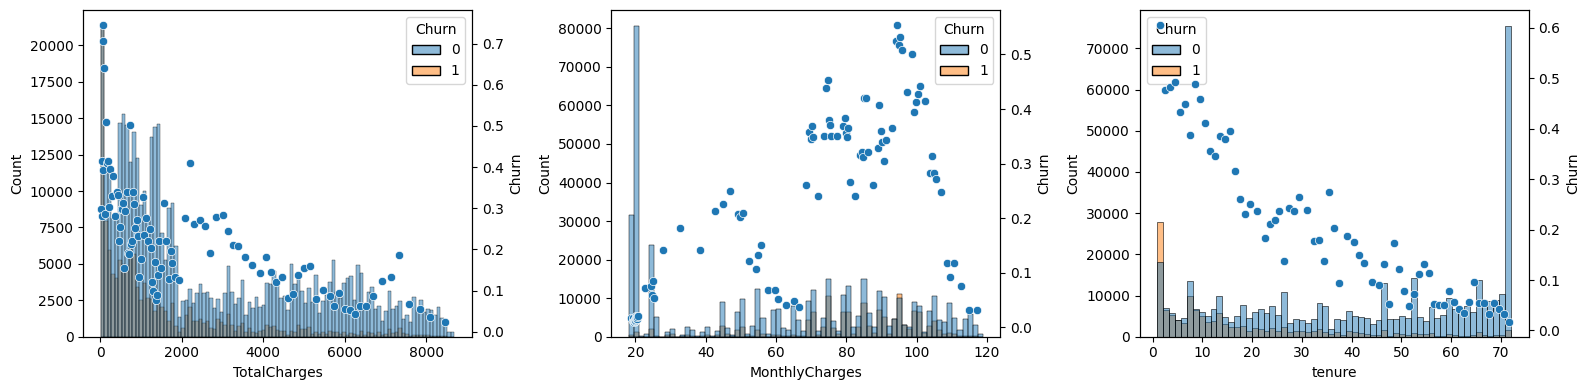

In [22]:
_, axes = plt.subplots(1, 3, figsize = (16, 4))
for i, ax in zip(X_num, axes.flatten()):
    sns.histplot(df_train, x = i, ax = ax, hue = target)
    df_train.groupby(pd.qcut(df_train[i], q = 100, duplicates = 'drop'), observed = True)[target].mean().reset_index().assign(
        q_median = lambda x: (x[i].cat.categories.left + x[i].cat.categories.right) / 2
    ).pipe(
        lambda x: sns.scatterplot(x, x = 'q_median', y = target, ax = ax.twinx())
    )
plt.tight_layout()
plt.show()

In [23]:
roc_auc_score(df_train[target], -df_train['tenure'])

0.7936764118576458

In [24]:
roc_auc_score(df_train[target], df_train['MonthlyCharges'])

0.6790063142581958

In [25]:
roc_auc_score(df_train[target], -df_train['TotalCharges'])

0.6678535948669334

In [26]:
df_train[X_num].corr().unstack().rename('corr').reset_index().query('level_0 < level_1')

,level_0,level_1,corr
2,TotalCharges,tenure,0.769703
3,MonthlyCharges,TotalCharges,0.634237
5,MonthlyCharges,tenure,0.124043


In [27]:
df_train.query('tenure == 1').pipe(
    lambda x: x['MonthlyCharges'] - x['TotalCharges']
).value_counts(normalize=True)

 0.000000      0.911281
-1.000000      0.022685
 1.000000      0.016894
-2.000000      0.004797
 2.000000      0.003290
                 ...   
-422.750000    0.000034
 5.400002      0.000034
 30.199999     0.000034
-75.199997     0.000034
 30.750000     0.000034
Name: proportion, Length: 418, dtype: float64

In [28]:
roc_auc_score(df_train[target], df_train['MonthlyCharges'] / df_train['tenure'])

0.8557175787629429

In [29]:
roc_auc_score(df_train[target], df_train['TotalCharges'] / df_train['tenure'])

0.6834943642074567

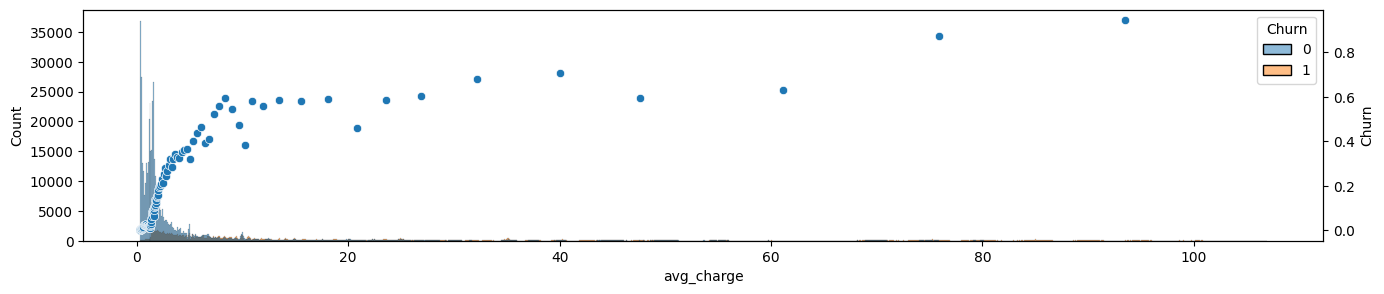

In [32]:
plt.figure(figsize=(16, 3))
ax = plt.gca()
avg_charge = (df_train['MonthlyCharges'] / df_train['tenure']).rename('avg_charge')
sns.histplot(x=avg_charge, ax = ax, hue = df_train[target])
df_train.groupby(pd.qcut(avg_charge, q = 100, duplicates = 'drop'), observed = True)[target].mean().reset_index().assign(
    q_median = lambda x: (x['avg_charge'].cat.categories.left + x['avg_charge'].cat.categories.right) / 2
).pipe(
    lambda x: sns.scatterplot(x, x = 'q_median', y = target, ax = ax.twinx())
)
plt.show()

- Monthly Charge는 어떠한 요금제를 나타낼 수도 있지 않을까?

In [33]:
df_train['MonthlyCharges'].value_counts()

MonthlyCharges
20.049999    7436
19.950001    5718
19.700001    5705
20.000000    5493
19.850000    5114
             ... 
32.450001       1
31.299999       1
89.239998       1
21.700001       1
46.150002       1
Name: count, Length: 1921, dtype: int64

In [34]:
roc_auc_score(
    df_train[target], df_train.groupby('MonthlyCharges')[target].transform('mean')
)

0.779535041604032

In [35]:
from sklearn.preprocessing import TargetEncoder

tgt = TargetEncoder()
roc_auc_score(
    df_train[target], tgt.fit_transform(df_train[['MonthlyCharges']], df_train[target])[:, 0]
)

0.7747667602793329

- 범주형으로 시도해볼만하지만, 저빈도가 보이므로 이를 OOV를 감안한 처리가 필요하지 않을까함

# ML pilot & Analysis

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from mllabs.nn import NNClassifier
from mllabs import ColSelector
from mllabs.adapter import XGBoostAdapter, LightGBMAdapter, CatBoostAdapter
from mllabs.collector import SHAPCollector
from mllabs.filter import RandomFilter
from mllabs.col import ohe_drop_first

In [37]:
df_train['mt_ratio'] = df_train['TotalCharges'] / df_train['tenure']
X_num = X_num[:3] # idempotent
X_num.append('mt_ratio')

## 실험을 위한 기반 설정 작업

In [38]:
if os.path.exists('exp/analysis'):
    e_aml = Experimenter.load('exp/analysis', df_train)
    if e_aml.status == 'closed':
        e_aml.reopen_exp()
else:
    e_aml = Experimenter.create(
        df_train, 'exp/analysis', title='파일럿과 데이터 탐색을 위한 ML 실험',
        sp=StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=1),
        sp_v=StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=1),
        splitter_params={'y': target}
    )
Markdown(
    e_aml.desc_spec()
)

📁 Created directory: exp/analysis


## 파일럿과 데이터 탐색을 위한 ML 실험

| 항목 | 값 |
|------|-----|
| **Outer Splitter (sp)** | `StratifiedShuffleSplit(n_splits=1, random_state=1, test_size=0.3)` |
| **Inner Splitter (sp_v)** | `StratifiedShuffleSplit(n_splits=1, random_state=1, test_size=0.1)` |
| **Splitter Params** | `{y='Churn'}` |
| **Outer Folds** | 1 |
| **Inner Folds** | 1 |

In [39]:
# Pipeline 구성

e_aml.set_grp('pre', role='stage', method='transform')
y_edges = {'y': [(None, target)]}
e_aml.set_grp(
    'clf', role='head', method='predict_proba', edges=y_edges
)

# XGBoost
e_aml.set_grp('xgb', parent='clf', processor=xgb.XGBClassifier,
    adapter=XGBoostAdapter(eval_mode='both'),
    params={
        'n_estimators': 10000, 'learning_rate': 0.05, 'early_stopping_rounds': 50, 'eval_metric': 'auc', 'enable_categorical': True,
        'verbosity': 0, 'random_state': 1,
    }
)
e_aml.add_collector(
    ModelAttrCollector('xgb_evals_results', Connector(processor=xgb.XGBClassifier), 'evals_result')
)

# LightGBM
e_aml.set_grp('lgb', parent='clf', processor=lgb.LGBMClassifier,
    adapter=LightGBMAdapter(eval_mode='both'),
    params={
        'n_estimators': 10000, 'learning_rate': 0.05,
        'early_stopping': lgb_early_stopping(50, first_metric_only=True),
        'eval_metric': 'auc', 'verbose': -1, 'random_state': 1,
    }
)
e_aml.add_collector(
    ModelAttrCollector('lgb_evals_results', Connector(processor=lgb.LGBMClassifier), 'evals_result')
)

# CatBoost
e_aml.set_grp('cb', parent='clf', processor=cb.CatBoostClassifier,
    adapter=CatBoostAdapter(eval_mode='both'),
    params={
        'iterations': 10000, 'learning_rate': 0.05, 'early_stopping_rounds': 50,
        'eval_metric': 'AUC', 'verbose': 0, 'random_state': 1,
    }
)
e_aml.add_collector(
    ModelAttrCollector('cb_evals_results', Connector('_base$', processor=cb.CatBoostClassifier), 'evals_result') # GPU는 수집할 수 없어서 제외(GPU는 _gpu로 끝나게 설정)
)

# LogisticRegression
e_aml.set_grp('lr', parent='clf', processor=LogisticRegression,
    params={
        'max_iter': 1000, 'random_state': 1,
    }
)

# DecisionTreeClassifier
e_aml.set_grp('dt', parent='clf', processor=DecisionTreeClassifier,
    params={
        'max_depth': 4, 'random_state': 1, # 주요 요인이 무엇인지 파악하기 위함
    }
)

## Neural network
e_aml.set_grp('nn', parent = 'clf', processor = NNClassifier, params = {'metrics': ['auc'], 'early_stopping': 10})
e_aml.add_collector(
    ModelAttrCollector('nn_evals', Connector(processor=NNClassifier), result_key='evals_result')
)

Collect 1/1 (100%)       
Collect 1/1 (100%)       
Collect 1/1 (100%)       
Collect 1/1 (100%)       


In [40]:
# Collector 구성

e_aml.add_collector(
    MetricCollector(
        'AUC',
        Connector(edges=y_edges), slice(-1, None), roc_auc_score, include_train = True
    )
)

# Feature importance — LGB
e_aml.add_collector(
    ModelAttrCollector(
        'lgb_feature_importance',
        Connector(processor=lgb.LGBMClassifier, edges=y_edges),
        'feature_importances'
    )
)

# Feature importance — XGB
e_aml.add_collector(
    ModelAttrCollector(
        'xgb_feature_importance_gain',
        Connector(processor=xgb.XGBClassifier, edges=y_edges),
        'feature_importances', params = {'importance_type': 'gain'}
    )
)

e_aml.add_collector(
    ModelAttrCollector(
        'xgb_feature_importance_cover',
        Connector(processor=xgb.XGBClassifier, edges=y_edges),
        'feature_importances', params = {'importance_type': 'cover'}
    )
)

# CatBoost feature importance (PredictionValuesChange)
e_aml.add_collector(
    ModelAttrCollector(
        'cb_feature_importance',
        Connector(processor=cb.CatBoostClassifier, edges=y_edges),
        'feature_importances_pvc'
    )
)

# CatBoost feature interaction importance
e_aml.add_collector(
    ModelAttrCollector(
        'cb_interaction',
        Connector(processor=cb.CatBoostClassifier, edges=y_edges),
        'feature_importances_interaction'
    )
)

# LogisticRegression coef
e_aml.add_collector(
    ModelAttrCollector(
        'lr_coef',
        Connector(processor=LogisticRegression, edges=y_edges),
        'coef'
    )
)

Collect 1/1 (100%)       
Collect 1/1 (100%)       
Collect 1/1 (100%)       
Collect 1/1 (100%)       
Collect 1/1 (100%)       
Collect 1/1 (100%)       
Collect 1/1 (100%)       


In [41]:
set(df_train.columns) - set(X_bin + X_nom + X_tri + X_num)

{'Churn',
 'DSL_Y',
 'DeviceProtection_Y',
 'MultipleLines_Y',
 'No_Internet',
 'OnlineBackup_Y',
 'OnlineSecurity_Y',
 'StreamingMovies_Y',
 'StreamingTV_Y',
 'TechSupport_Y'}

## 실험 수행

In [42]:
e_aml.set_node('ohe', processor = OneHotEncoder, grp='pre', edges = {'X': [(None, X_nom)]}, params = {'sparse_output': False})
e_aml.set_node('std', processor = StandardScaler, grp='pre', edges = {'X': [(None, X_num)]})
e_aml.build()

Building 2 node(s)
Build 1/1 (100%)               
Build complete: 2 node(s)


In [43]:
e_aml.set_node('xgb_base', grp='xgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num)]})
e_aml.set_node('lgb_base', grp='lgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num)]}, params={'categorical_features': ColSelector(col_type = 'category')})
e_aml.set_node('cb_base', grp='cb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num)]}, params={'cat_features': ColSelector(col_type = 'category')})
e_aml.set_node('dt_base', grp='dt', edges = {'X': [(None, X_bin + X_bin2 + X_num), ('ohe', None)]})
e_aml.set_node('lr_base', grp='lr', edges = {'X': [(None, X_bin + X_bin2), ('std', None), ('ohe', ohe_drop_first)]})
e_aml.set_node('nn_base', grp = 'nn', edges = {'X': [(None, X_bin + X_nom + X_bin2), ('std', None)]})
e_aml.exp()

Experimenting 6 node(s)
Exp 0/1 (0%) > lgb_base 1/6 (16%) > 1/10000 (0%) valid_0-auc: 0.9029, valid_0-binary_logloss: 0.5130, valid_1-auc: 0.9030, valid_1-binary_logloss: 0.5129Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[655]	valid_0's auc: 0.924048	valid_0's binary_logloss: 0.285082	valid_1's auc: 0.917028	valid_1's binary_logloss: 0.2971
Evaluated only: auc
Exp 0/1 (0%) > nn_base 4/6 (66%)                                                                                                                         

I0000 00:00:1772808296.304855    1623 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5518 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Exp 1/1 (100%)                                                                                              
Experimentation complete: 6 node(s)


## 결과 분석

### 학습시간 (초)

In [44]:
pd.Series({
    i: next(e_aml.get_objs(i, 0))[2]['fit_time']
    for i in ['xgb_base', 'lgb_base', 'cb_base', 'dt_base', 'lr_base', 'nn_base']
}).sort_values(ascending = False)

nn_base     151.644042
cb_base     125.904792
lgb_base      8.791461
xgb_base      7.210137
lr_base       2.113381
dt_base       0.507633
dtype: float64

- CatBoost가 가장 오래걸림..

In [47]:
e_aml.set_node('cb_base_gpu', grp='cb', processor=cb.CatBoostClassifier,
    adapter=CatBoostAdapter(eval_mode='eval'), # GPU에서는 eval셋을 하나만 사용가능
    edges = {'X': [(None, X_bin + X_nom + X_tri + X_num)]}, params={'task_type': 'GPU', 'cat_features': ColSelector(col_type = 'category')}
)
e_aml.exp()

Experimenting 1 node(s)
Exp 0/1 (0%) > cb_base_gpu 0/1 (0%)

Default metric period is 5 because AUC is/are not implemented for GPU


Exp 1/1 (100%)                       
Experimentation complete: 1 node(s)


- CatBoost에 gpu를 사용하여 속도를 높여보자

In [48]:
pd.Series({
    i: next(e_aml.get_objs(i, 0))[2]['fit_time']
    for i in ['xgb_base', 'lgb_base', 'cb_base', 'cb_base_gpu', 'dt_base', 'lr_base', 'nn_base']
}).sort_values(ascending = False)

cb_base_gpu    343.709185
nn_base        151.644042
cb_base        125.904792
lgb_base         8.791461
xgb_base         7.210137
lr_base          2.113381
dt_base          0.507633
dtype: float64

In [63]:
len(
    next(e_aml.get_objs('cb_base', 0))[0].obj.evals_result_['learn']['Logloss']
)

1072

In [62]:
len(
    next(e_aml.get_objs('cb_base_gpu', 0))[0].obj.evals_result_['learn']['Logloss']
)

2001

- CatBoost GPU와 CPU의 동작이 차이가 많은 편이라 생각하는 데, 거의 모든 세팅을 디폴트로 했지만 결과의 차이를 보이는데, 버전에 따라 결과가 오락가락 한다.
- 위 경우는 GPU로 하니 시간이 오래 걸렸다, 또한 학습이 멈춘 라운드도 두 배 차이가 났다.

### AUC

- Early Stopping를 제외한 기본 파라미터의 성능이니 참고용으로 봄

In [64]:
e_aml.get_collector('AUC').get_metrics_agg('.*_base$|._gpu$')[0].sort_values('valid', ascending = False)

,valid,train_sub,valid_sub
cb_base,0.915478,0.919196,0.916974
xgb_base,0.915396,0.924214,0.916982
lgb_base,0.915304,0.924048,0.917028
cb_base_gpu,0.913405,0.931467,0.914754
nn_base,0.912480,0.915604,0.914554
lr_base,0.907455,0.908050,0.908985
dt_base,0.894513,0.894691,0.895593


- CB에서 GPU 사용에 의해 달리 작동함에 따라 성능의 차이가 확인 됨

### Plot tree

In [65]:
from sklearn.tree import plot_tree

In [66]:
proc = next(e_aml.get_objs('dt_base', 0))[0]
proc.obj, proc.X_[:3]

(DecisionTreeClassifier(max_depth=4, random_state=1),
 ['Dependents', 'PaperlessBilling', 'Partner'])

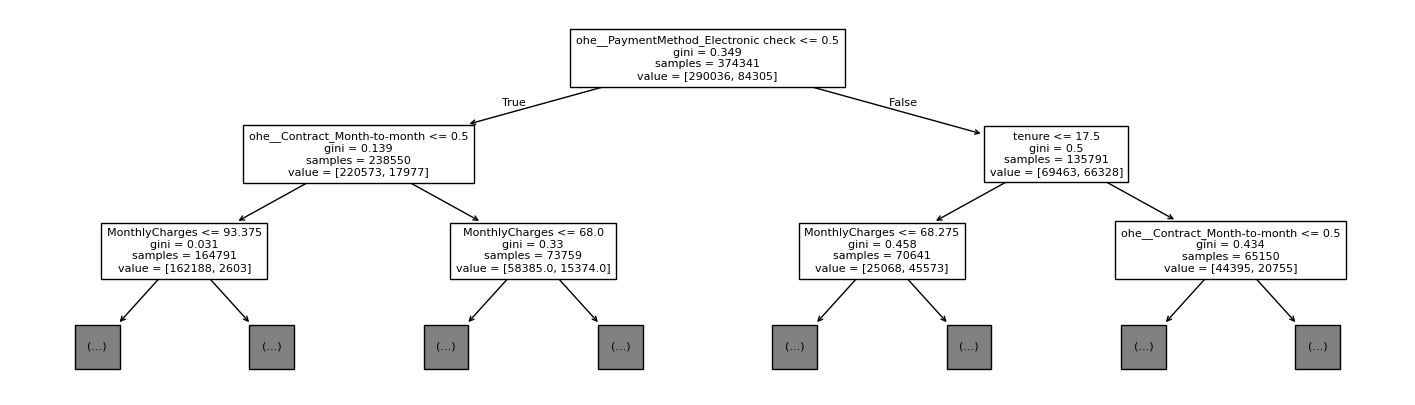

In [67]:
plt.figure(figsize = (18, 5))

plot_tree(
    proc.obj, max_depth = 2, feature_names = proc.X_, fontsize = 8
)
plt.show()

### Feature Importance

In [68]:
# 연결하지 않고 개별적으로 사용가능
shap_col = SHAPCollector(
    'shap',
    Connector(processor=xgb.XGBClassifier),
    data_filter=RandomFilter(frac=0.1, random_state=1)
)
e_aml.collect(shap_col)

Collect 1/1 (100%)                    


In [69]:
pd.concat([
    e_aml.collectors['lgb_feature_importance'].get_attrs_agg('lgb_base').pipe(
        lambda x: x / x.sum()
    ).rename('lgb'),
    e_aml.collectors['xgb_feature_importance_gain'].get_attrs_agg('xgb_base').pipe(
        lambda x: x / x.sum()
    ).rename('xgb_gain'),
    e_aml.collectors['xgb_feature_importance_cover'].get_attrs_agg('xgb_base').pipe(
        lambda x: x / x.sum()
    ).rename('xgb_cover'),
    e_aml.collectors['cb_feature_importance'].get_attrs_agg('cb_base').pipe(
        lambda x: x / x.sum()
    ).rename('cb'),
    shap_col.get_feature_importance_agg('xgb_base').pipe(lambda x: x / x.sum()).rename('xgb_shap')
], axis = 1).pipe(
    lambda x: x.iloc[np.argsort(-x.sum(axis=1))]
)

,lgb,xgb_gain,xgb_cover,cb,xgb_shap
Contract,0.032672,0.385472,0.082325,0.188048,0.312617
InternetService,0.008397,0.419611,0.120529,0.022696,0.096416
tenure,0.115420,0.025640,0.077315,0.217366,0.103449
MonthlyCharges,0.205089,0.002854,0.056219,0.128205,0.037335
TotalCharges,0.213893,0.003143,0.085846,0.068370,0.050460
mt_ratio,0.190789,0.004632,0.043186,0.107989,0.065113
PaymentMethod,0.022188,0.046912,0.024903,0.091013,0.082414
PaperlessBilling,0.020560,0.010944,0.051110,0.031844,0.036736
OnlineSecurity,0.017964,0.020336,0.032621,0.033491,0.044784
MultipleLines,0.021730,0.008458,0.053841,0.020506,0.033278


- 전반적으로 Contract가 중요한 변수로 보이지만, 모델과 방법에 따라 중요성을 보이는 게 차이가 남. Boosting에서 공선성이 존재하기도 하니 컬럼 샘플링이 효과성이 있을 듯함

### Interaction

In [70]:
e_aml.get_collector('cb_interaction').get_attrs_agg('cb_base').sort_values(ascending = False).iloc[:20]

feat1           feat2         
TotalCharges    MonthlyCharges    8.826865
                mt_ratio          6.595920
                tenure            5.824114
MonthlyCharges  mt_ratio          5.528428
                tenure            5.290089
tenure          mt_ratio          3.803151
Contract        TotalCharges      2.051496
                tenure            1.991427
PaymentMethod   TotalCharges      1.967826
                tenure            1.782574
Contract        MonthlyCharges    1.516064
PaymentMethod   MultipleLines     1.482609
OnlineBackup    TotalCharges      1.296361
MultipleLines   TotalCharges      1.290375
PaymentMethod   MonthlyCharges    1.241399
MultipleLines   tenure            1.216481
Contract        MultipleLines     1.193000
PaymentMethod   mt_ratio          1.191852
TechSupport     TotalCharges      1.165795
Contract        mt_ratio          1.031420
dtype: float64

### Coefficient of LR

In [71]:
e_aml.get_collector('lr_coef').get_attrs_agg('lr_base').pipe(
    lambda x: x.iloc[np.argsort(-x.abs())]
)

0  No_Internet                                  -2.057745
   std__tenure                                  -1.843806
   intercept                                    -1.583219
   ohe__Contract_Two year                       -1.394397
   DSL_Y                                        -0.991805
   std__TotalCharges                             0.826864
   ohe__Contract_One year                       -0.762044
   ohe__PaymentMethod_Electronic check           0.674031
   PhoneService                                 -0.515616
   SeniorCitizen                                 0.439797
   PaperlessBilling                              0.406255
   OnlineSecurity_Y                             -0.376698
   StreamingTV_Y                                 0.376153
   MultipleLines_Y                               0.352179
   StreamingMovies_Y                             0.337248
   Dependents                                   -0.333310
   TechSupport_Y                                -0.227947
   OnlineBacku

### Learning Curve

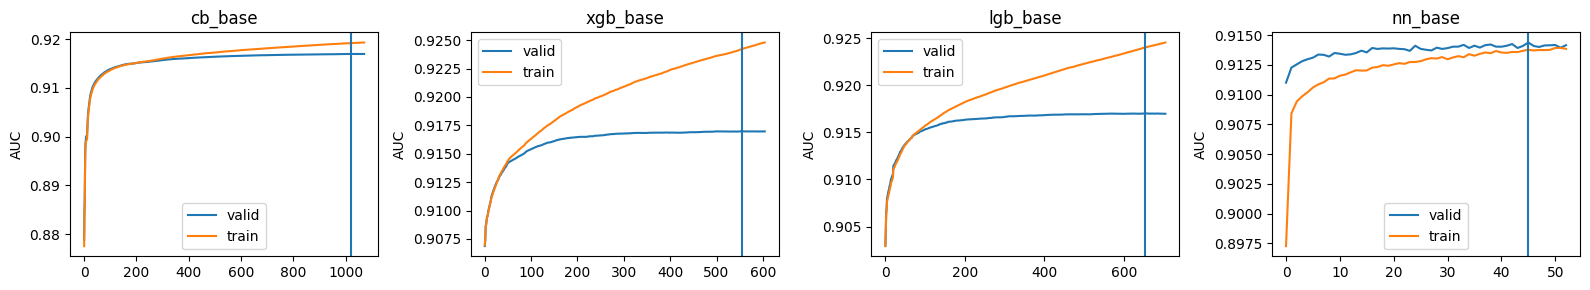

In [94]:
_, axes = plt.subplots(1, 4, figsize = (16, 3))
def plot_eval_result(name, ax, s_train, s_valid):
    sns.lineplot(s_valid, ax=ax, label = 'valid')
    sns.lineplot(s_train, ax=ax, label = 'train')
    ax.set_ylabel('AUC')
    ax.axvline(s_valid.argmax())
    ax.set_title(name)
    ax.legend()

d = e_aml.get_collector('cb_evals_results').get_attrs()
eval_result = d['cb_base'][0][0].unstack(level=[1, 2])
plot_eval_result(
    'cb_base', axes[0],
    eval_result[('AUC', 'validation_0')].rename('train'),
    eval_result[('AUC', 'validation_1')].rename('valid')
)
d = e_aml.get_collector('xgb_evals_results').get_attrs()
eval_result = d['xgb_base'][0][0].unstack(level=[1, 2])
plot_eval_result(
    'xgb_base', axes[1],
    eval_result[('auc', 'validation_0')].rename('train'),
    eval_result[('auc', 'validation_1')].rename('valid')
)
d = e_aml.get_collector('lgb_evals_results').get_attrs()
eval_result = d['lgb_base'][0][0].unstack(level=[1, 2])
plot_eval_result(
    'lgb_base', axes[2],
    eval_result[('auc', 'valid_0')].rename('train'),
    eval_result[('auc', 'valid_1')].rename('valid')
)
d = e_aml.get_collector('nn_evals').get_attrs()
eval_result = d['nn_base'][0][0].unstack(level=[1, 2])
plot_eval_result(
    'nn_base', axes[3],
    eval_result[('auc', 'train')].rename('train'),
    eval_result[('auc', 'valid')].rename('valid')
)
plt.tight_layout()
plt.show()

## 속성 공학 파일럿

### mt_ratio를 빼면?

- 분석 과정에서 실수로 파생변수를 포함, 순수하게 제공된 변수만으로 사용했을 때를 본다
- 처음부터 포함하고 갔지만, 이름 뺀 모델의 성능은?

In [95]:
e_aml.set_node('xgb_base2', grp='xgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num[:-1])]})
e_aml.set_node('lgb_base2', grp='lgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num[:-1])]}, params={'categorical_features': ColSelector(col_type = 'category')})
e_aml.set_node('cb_base2', grp='cb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num[:-1])]}, params={'cat_features': ColSelector(col_type = 'category')})
e_aml.exp()

Experimenting 3 node(s)
Exp 0/1 (0%) > lgb_base2 2/3 (66%) > 1/10000 (0%) valid_0-auc: 0.9028, valid_0-binary_logloss: 0.5130, valid_1-auc: 0.9031, valid_1-binary_logloss: 0.5129Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[514]	valid_0's auc: 0.921835	valid_0's binary_logloss: 0.28879	valid_1's auc: 0.916802	valid_1's binary_logloss: 0.29748
Evaluated only: auc
Exp 1/1 (100%)                                                                                                                                            
Experimentation complete: 3 node(s)


In [96]:
e_aml.get_collector('AUC').get_metrics_agg('xgb.*|lgb.*|cb.*')[0].sort_values('valid', ascending = False)

,valid,train_sub,valid_sub
cb_base2,0.915525,0.919330,0.917035
cb_base,0.915478,0.919196,0.916974
xgb_base,0.915396,0.924214,0.916982
lgb_base,0.915304,0.924048,0.917028
xgb_base2,0.915241,0.922985,0.916720
lgb_base2,0.915226,0.921835,0.916802
cb_base_gpu,0.913405,0.931467,0.914754


In [97]:
e_aml.get_collector('cb_interaction').get_attrs_agg('cb_base2').sort_values(ascending = False).iloc[:20]

feat1             feat2         
TotalCharges      MonthlyCharges    12.938561
                  tenure            12.428400
MonthlyCharges    tenure             9.270028
PaymentMethod     TotalCharges       2.350781
Contract          TotalCharges       2.311913
PaymentMethod     MonthlyCharges     1.926376
Contract          MonthlyCharges     1.907223
                  tenure             1.835189
PaymentMethod     tenure             1.722293
TechSupport       TotalCharges       1.399291
MultipleLines     TotalCharges       1.341633
DeviceProtection  TotalCharges       1.243738
OnlineSecurity    TotalCharges       1.194042
PaymentMethod     MultipleLines      1.188971
InternetService   TotalCharges       1.174696
OnlineBackup      TotalCharges       1.138682
InternetService   tenure             1.089382
StreamingMovies   TotalCharges       1.071903
Contract          MultipleLines      1.037106
MultipleLines     tenure             1.001586
dtype: float64

- mt_ratio는 딱히 유의미성이 보이지 않는 듯

### MonthlyCharges를 Categorical 변수로

In [98]:
from mllabs.processor import CatConverter
from sklearn.preprocessing import TargetEncoder

In [99]:
e_aml.set_node('n2c', processor = CatConverter, grp='pre', edges = {'X': [(None, ['MonthlyCharges'])]})
e_aml.build()

Building 1 node(s)
Build 1/1 (100%)               
Build complete: 1 node(s)


In [100]:
e_aml.set_node('xgb_base3', grp='xgb', edges = {'X': [(None, X_bin + X_nom + X_tri + ['TotalCharges', 'tenure']), ('n2c', None)]}, desc = "MonthlyCharges를 카테고리변수로")
e_aml.exp()

Experimenting 1 node(s)
Exp 0/1 (0%) > xgb_base3 0/1 (0%)[xgb_base3] Exp error at fold 0: XGBoostError: [00:42:15] /__w/xgboost/xgboost/src/data/columnar.h:134: Category index from DataFrame has floating point dtype, consider using strings or integers instead.
Stack trace:
  [bt] (0) /home/sun9sun9/python312/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0x2c1a8c) [0x7e2f94ec1a8c]
  [bt] (1) /home/sun9sun9/python312/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0x4e38f0) [0x7e2f950e38f0]
  [bt] (2) /home/sun9sun9/python312/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0x4e534d) [0x7e2f950e534d]
  [bt] (3) /home/sun9sun9/python312/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0x4e5478) [0x7e2f950e5478]
  [bt] (4) /home/sun9sun9/python312/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0x4dd494) [0x7e2f950dd494]
  [bt] (5) /home/sun9sun9/python312/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0x6897b5) [0x7e2f952897b5]
  [bt] (6) /

In [ ]:
e_aml.get_collector('AUC').get_metrics_agg('xgb.*')[0].sort_values('valid', ascending = False)

In [ ]:
e_aml.set_node('tgt', grp='pre', processor = TargetEncoder, method = 'fit_transform', edges = {'X': [(None, ['MonthlyCharges'])], 'y': [(None, target)]})
e_aml.set_node('xgb_base4', grp='xgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num), ('tgt', None)]}, desc = "MonthlyCharges를 타겟인코딩")
e_aml.build()
e_aml.exp()

In [ ]:
e_aml.get_collector('AUC').get_metrics_agg('xgb.*')[0].sort_values('valid', ascending = False)

In [ ]:
e_aml.set_node('lr_base2', grp='lr', edges = {'X': [(None, X_bin + X_bin2 + X_num), ('ohe', ohe_drop_first), ('tgt', None)]}, desc = "MonthlyCharges를 타겟인코딩")
e_aml.exp()

In [ ]:
e_aml.get_collector('AUC').get_metrics_agg('lr.*')[0].sort_values('valid', ascending = False)

- 큰 효과성은 보이지 않는듯

-----

본격적인 모델링은 다음 노트에서...